# Deformation potentials, surrogates, and where they break

**Goal.** Deformation potentials $\Xi = dE_\text{band}/d\varepsilon$ — the slope of a band energy against
strain — are extracted here from DFT (VASP, PAW-PBE). We try to settle two questions about that procedure by experimenting
and trying to find rigorous formulations for.

1. PBE gets the band gap ~50% wrong, yet PBE deformation potentials are widely used. Why is that legitimate?
2. If the expensive DFT calls are replaced by a fitted surrogate, can the surrogate still be differentiated (are the derivatives of surrogate models trustworthy)?

Both answers reduce to the same statement about **the wavelength of the error**. We first build that statement
, then follow it until it stops working on the $\pi_{44}$ problem.

**Roadmap:** Part 1 builds the wavelength argument. Part 2 shows the standard fix — putting the derivative in
the loss, which is what `MLIP`s do. Part 3 shows where that fix does not transfer, and why.

We try to check all of these against an analytic ground truth, so every claim in the text corresponds to a number
or a figure produced in the cell above it. 

Runs on CPU in a few minutes; requires only `numpy`, `matplotlib`
and `torch`.

## Some domain vocabulary I fount out from literarute (Concepts and references)

**Fourier decomposition.** Any function on an interval is a sum of sines of different wavelengths $\lambda$.
This is only a change of basis, but it is the right one here because differentiation acts on each sine
*independently*.

**Differentiation multiplies by frequency.** If $f = \sum_k c_k e^{ikx}$ then $f' = \sum_k (ik)\,c_k e^{ikx}$.
Mode $k = 2\pi/\lambda$ returns scaled by $k$: long wavelengths are shrunk, short wavelengths amplified.
This is the sense in which numerical differentiation is *ill-posed* — the operator is unbounded and has no
finite condition number.
Trefethen, *Spectral Methods in MATLAB* (2000), Ch. 1–3.

**Probing with a single mode.** To determine what an operator does to an error, apply it to one sine and
measure. This is the same device as von Neumann stability analysis for finite-difference schemes.
LeVeque, *Finite Difference Methods for ODEs and PDEs* (2007), §9.5.

**Spectral bias**, also called the *frequency principle*. Networks trained by gradient descent fit low
frequencies first and high frequencies last or not at all, so a surrogate's residual error is preferentially
*high* frequency — precisely the part differentiation amplifies.
Rahaman et al., *On the Spectral Bias of Neural Networks*, ICML 2019, arXiv:1806.08734, §2: ReLU networks are
biased toward low frequency and cannot produce local fluctuations without affecting global behaviour.
Kiessling & Thor, *A Computable Definition of the Spectral Bias*, AAAI 2022, gives a measurable definition.
In machine learning this bias is usually described as beneficial regularisation; for scientific computing it
is a limitation, since the high-frequency content is also required.

**Automatic differentiation.** The forward pass is recorded as a graph and the chain rule applied backwards.
The same machinery that yields $\partial(\text{loss})/\partial(\text{weights})$ yields
$\partial(\text{output})/\partial(\text{input})$, which is the quantity of interest here.

**Gradient-domain (derivative-aware) learning.** Training on values and derivatives jointly.
Chmiela et al., *Machine learning of accurate energy-conserving molecular force fields*, Sci. Adv. 3,
e1603015 (2017).

**Hellmann–Feynman theorem.** For a non-degenerate eigenstate,
$dE/d\lambda = \langle\psi|\,\partial H/\partial\lambda\,|\psi\rangle$, with no derivative of $\psi$ required.
This is beacsse: $H_\lambda |\psi_\lambda\rangle = E_\lambda|\psi_\lambda\rangle$, and  $\langle\psi_\lambda|\psi_\lambda\rangle = 1 \Rightarrow \frac{d}{d\lambda}\langle\psi_\lambda|\psi_\lambda\rangle = 0.$

Consequently DFT returns forces essentially free alongside the energy, which is what makes derivative labels
affordable for MLIPs. The non-degeneracy condition becomes important in Part 3.

**MLIP / Behler–Parrinello decomposition.** Total energy as a sum of local atomic contributions, each
produced by a shared network acting on a *descriptor* of the local environment.
Behler & Parrinello, PRL 98, 146401 (2007).

**Invariance and equivariance.** An invariant output is unchanged under a symmetry operation; an equivariant
output transforms with it, as vector quantities such as forces must. Feeding a network bond lengths rather
than positions makes translation invariance exact by construction instead of approximate by training.

**Degenerate perturbation theory.** When states are degenerate, the first-order shifts are not
$\langle\psi_i|\partial H|\psi_i\rangle$ for an arbitrary basis of the subspace. The correct slopes are the
eigenvalues of $\partial H$ projected onto that subspace.
Yu & Cardona, *Fundamentals of Semiconductors*, §2.6; Bir & Pikus for the strain case.

**DeepH-class models.** Surrogates predicting the Hamiltonian matrix $H(R)$ rather than band energies, with
diagonalisation performed afterwards.
Li et al., *Deep-learning density functional theory Hamiltonian*, Nat. Comput. Sci. 2, 367 (2022).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(0); np.random.seed(0)
plt.rcParams['figure.dpi'] = 110
print("torch", torch.__version__)

torch 2.13.0+cu132


---
# Part 1 — the importance of error wavelength 

The claim:

> Differentiation **suppresses** long-wavelength error and **amplifies** short-wavelength error.
> Where we show wavelength by $\lambda$.

It follows that PBE's error is long-$\lambda$ in strain and cancels, while a surrogate's error is
short-$\lambda$ and is amplified.

## 1.1 A toy energy surface

We have devised a surface that somehow has a wiggly approximation, and also the analytical derivative is known 

Here $x$ stands for strain rescaled to $[-1,1]$; the argument concerns wavelengths, so units do not enter.

In [13]:
def energy_true(x):
    '''toy E(x): smooth trend + a couple of sharp features + a fast ripple'''
    return (3.0*np.sin(0.8*x)*np.cos(1.2*x+0.5)
            - 2.5*np.exp(-((x-2.0)**2)/0.3) - 1.8*np.exp(-((x+1.5)**2)/0.2)
            + 1.5*np.exp(-0.2*x)*np.sin(2.0*x)
            + 0.05*x**3 - 0.3*x**2 + 0.5*x
            + 0.4*np.sin(4.5*x+1.2)*np.exp(-0.1*x**2)

            # adding a tight guassina bumb
            + 0.6*np.exp(-((x-0.15)**2)/0.002)
            - 0.6*np.cos(3.0*x)*np.exp(-0.15*(x+1.0)**2))

def dE_dx(x):
    '''analytic derivative, by hand'''
    return (3.0*(0.8*np.cos(0.8*x)*np.cos(1.2*x+0.5) - 1.2*np.sin(0.8*x)*np.sin(1.2*x+0.5))
            - 2.5*(-2.0*(x-2.0)/0.3)*np.exp(-((x-2.0)**2)/0.3)
            - 1.8*(-2.0*(x+1.5)/0.2)*np.exp(-((x+1.5)**2)/0.2)
            + 1.5*(-0.2*np.exp(-0.2*x)*np.sin(2.0*x) + 2.0*np.exp(-0.2*x)*np.cos(2.0*x))
            + 0.15*x**2 - 0.6*x + 0.5
                # derivative of the fast ripple
            + 0.4 * (
                4.5*np.cos(4.5*x + 1.2)*np.exp(-0.1*x**2)
                - 0.2*x*np.sin(4.5*x + 1.2)*np.exp(-0.1*x**2)
            )

            # derivative of -0.6 cos(3x) exp(-0.15(x+1)^2)
            - 0.6 * (
                -3.0*np.sin(3.0*x)*np.exp(-0.15*(x+1.0)**2)
                - 0.3*(x+1.0)*np.cos(3.0*x)*np.exp(-0.15*(x+1.0)**2)
            )

            # derivative of tight Gaussian
            + 0.6 * (
                -2*(x-0.15)/0.002
            ) * np.exp(-((x-0.15)**2)/0.002)
            )       

# a quick finite diff check
xc, h = np.linspace(-1, 1, 9), 1e-6
err = np.max(np.abs(dE_dx(xc) - (energy_true(xc+h) - energy_true(xc-h))/(2*h)))
assert err < 1e-7, err
print(f"analytic derivative matches finite difference to {err:.1e}")

xd = np.linspace(-1, 1, 2001)
print(f"E spans [{energy_true(xd).min():.2f}, {energy_true(xd).max():.2f}],  max|dE/dx| = {np.abs(dE_dx(xd)).max():.2f}")

analytic derivative matches finite difference to 4.2e-10
E spans [-4.03, 1.74],  max|dE/dx| = 16.81


## 1.2 Two error models

We devise two corrpution models of the true function:

- **PBE-like**: a large but smooth offset, $\Delta(x) = A(1 + 0.1x + 0.02x^2)$ with $A = 1.5$. Large in value,
  slowly varying — effectively a shifted copy across this window. This is the shape of a functional error:
  the gap is badly wrong, but its variation *against strain* is small.
- **surrogate-like**: a small but oscillatory error, $\delta\sin(2\pi x/\lambda)$ with $\delta = 0.05$,
  $\lambda = 0.15$, oscillating on the scale of the training point spacing.

By any value-based measure the second is the better approximation. The figure shows what differentiation
does to that judgement.

- We first calculate the true energies, then add a smoth error to the PBE like, and a wiggly one to the surrogate like. The derivatives follow as: 
- For surrogate like:

$$\frac{d}{dx}\left[E_{\text{true}} + \delta\sin\left(\frac{2\pi x}{\lambda}\right)\right] = \frac{dE_{\text{true}}}{dx} + \delta\left(\frac{2\pi}{\lambda}\right)\cos\left(\frac{2\pi x}{\lambda}\right)$$

- and similarly for PBE like.


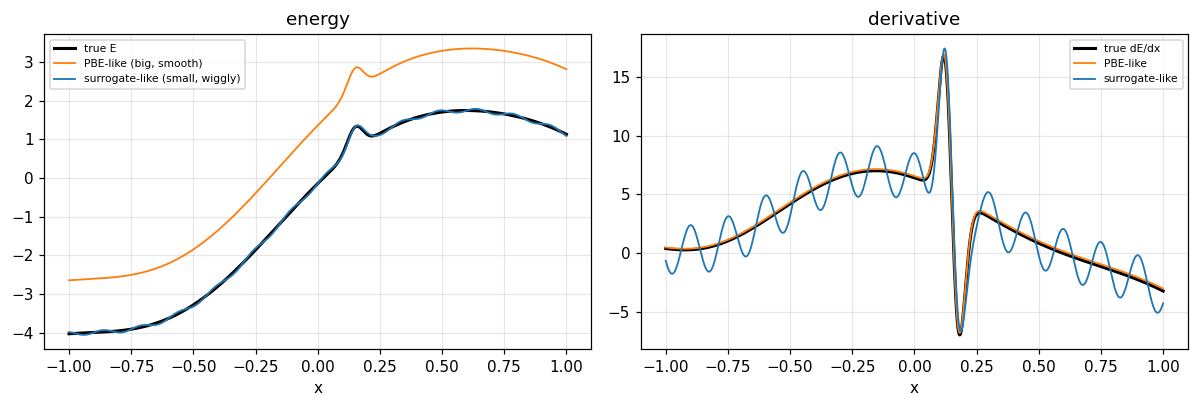

PBE-like       value err  1.680   deriv err  0.210   -> shrunk  x0.12
surrogate-like value err  0.050   deriv err  2.094   -> blown up x42

the surrogate error is 34x SMALLER in value but 10x LARGER in derivative


In [14]:
A = 1.5                                  # PBE-like: large amplitude, long wavelength
Delta   = A*(1 + 0.10*xd + 0.02*xd**2)
dDelta  = A*(0.10 + 0.04*xd)

d0, lam = 0.05, 0.15                     # surrogate-like: small amplitude, short wavelength
Wig     = d0*np.sin(2*np.pi*xd/lam)
dWig    = d0*(2*np.pi/lam)*np.cos(2*np.pi*xd/lam)


fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(xd, energy_true(xd), 'k', lw=2, label='true E')
ax[0].plot(xd, energy_true(xd)+Delta, color='tab:orange', lw=1.2, label='PBE-like (big, smooth)')
ax[0].plot(xd, energy_true(xd)+Wig,  color='tab:blue',  lw=1.2, label='surrogate-like (small, wiggly)')
ax[0].set_title('energy'); ax[0].set_xlabel('x'); ax[0].legend(fontsize=7)

ax[1].plot(xd, dE_dx(xd), 'k', lw=2, label='true dE/dx')
ax[1].plot(xd, dE_dx(xd)+dDelta, color='tab:orange', lw=1.2, label='PBE-like')
ax[1].plot(xd, dE_dx(xd)+dWig,  color='tab:blue',  lw=1.2, label='surrogate-like')
ax[1].set_title('derivative'); ax[1].set_xlabel('x'); ax[1].legend(fontsize=7)
for a_ in ax: a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"PBE-like       value err {np.abs(Delta).max():6.3f}   deriv err {np.abs(dDelta).max():6.3f}"
      f"   -> shrunk  x{np.abs(dDelta).max()/np.abs(Delta).max():.2f}")
print(f"surrogate-like value err {np.abs(Wig).max():6.3f}   deriv err {np.abs(dWig).max():6.3f}"
      f"   -> blown up x{np.abs(dWig).max()/np.abs(Wig).max():.0f}")
print(f"\nthe surrogate error is {np.abs(Delta).max()/np.abs(Wig).max():.0f}x SMALLER in value"
      f" but {np.abs(dWig).max()/np.abs(dDelta).max():.0f}x LARGER in derivative")

Left panel: the orange curve is visibly displaced while the blue one sits on the black. Any validation metric
based on energies prefers blue. Right panel: orange still tracks the truth; blue does not.

This is the argument we deal with. A 50% PBE gap error is the orange curve — a large offset that is nearly
constant across the strain window and therefore drops out of $d/d\varepsilon$. A surrogate that reproduces
energies closely is the blue curve.

## 1.3 Decomposing the error

For a single Fourier mode of amplitude $\delta$,

$$\text{err}(x) = \delta \sin(2\pi x/\lambda)
\quad\Longrightarrow\quad
\frac{d}{dx}\text{err}(x) = \delta\,\frac{2\pi}{\lambda}\cos(2\pi x/\lambda).$$

The value error is $\delta$ for every $\lambda$; the derivative error is $\delta\cdot 2\pi/\lambda$. Since any
error decomposes into such modes and differentiation acts on them independently, the single-mode result is
the general result. Sweeping $\lambda$ at fixed $\delta$ isolates the effect.

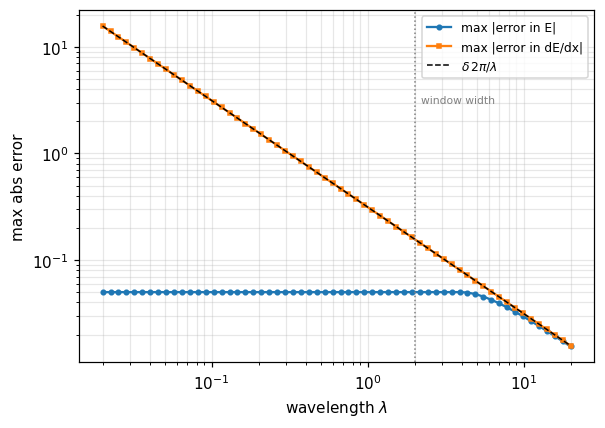

In [15]:
# numerically evaluating
delta = 0.05
x = np.linspace(-1, 1, 4001)
lams = np.logspace(np.log10(0.02), np.log10(20), 60)
val_err = np.array([np.max(np.abs(delta*np.sin(2*np.pi*x/L))) for L in lams])
der_err = np.array([np.max(np.abs(delta*(2*np.pi/L)*np.cos(2*np.pi*x/L))) for L in lams])

assert np.allclose(der_err, delta*2*np.pi/lams, rtol=1e-3), "1/lambda law broken" # comparing amplitudes: Amp(cos) = 1

plt.figure(figsize=(5.6, 4))
plt.loglog(lams, val_err, 'o-', ms=3, label='max |error in E|')
plt.loglog(lams, der_err, 's-', ms=3, label='max |error in dE/dx|')
plt.loglog(lams, delta*2*np.pi/lams, 'k--', lw=1, label=r'$\delta\,2\pi/\lambda$')
plt.axvline(2.0, color='gray', ls=':', lw=1)  # the width of the domain [-1,1]
plt.text(2.2, 3, 'window width', fontsize=7, color='gray') 
plt.xlabel(r'wavelength $\lambda$'); plt.ylabel('max abs error')
plt.legend(fontsize=8); plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()


- A wavelength larger than the window is the smooth, low-error one, and a wavelength smaller than the window is 
the one that oscillates and blows up.

- The dashed prediction lies on the measured points, so the law is exact rather than approximate. Everything to
the right of the grey line has wavelength longer than the window itself — the systematic-error regime, where
the error is an offset plus a gentle tilt and differentiation barely registers it. The far left is the
oscillatory regime.

- The value-error curve droops at large $\lambda$ because a long sine does not complete a period inside the
window, so its peak within the window falls below $\delta$. That is not an artefact: it is what a systematic
offset looks like over a narrow strain range.

## 1.4 An experimental result from a NN

Everything so far was injected by hand. The question is where a *fitted* network's error sits. Two mechanisms
push it to short $\lambda$:

- **sampling** — between training points the fit is unconstrained, so residual error oscillates on the scale
  of the spacing $h$, giving $\lambda \sim h$;
- **spectral bias** — gradient descent fits low frequencies first, so what remains unlearned is the
  high-frequency part (Rahaman et al. 2019).

Setup notes: `Tanh` rather than `ReLU` (§1.6), Adam rather than SGD, since the loss surface is badly
conditioned and plain SGD (with const learning rate) converges too slowly to be useful here. 
Model and optimiser are constructed in the
same cell — building the model separately leaves the optimiser bound to the previous object, so no training
occurs (google colab issue).

There is no train/validation/test split. The data is noiseless and deterministic and the exact answer is known
everywhere, so the dense grid serves as the test set; a split would only measure resampling of a known
function.

In [16]:
def fit_1d(x_train, y_train, act=nn.Tanh, epochs=6000, seed=0, lr=3e-3):
    '''fit a small MLP to (x,y); returns the model'''
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(1, 64), act(), nn.Linear(64, 64), act(), nn.Linear(64, 1))
    opt = torch.optim.Adam(model.parameters(), lr=lr)          # same cell as the model, always
    X = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
    Y = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    for _ in range(epochs):
        loss = ((model(X) - Y)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model

def value_and_slope(model, x):
    '''the model's OWN derivative, by autodiff'''
    xt = torch.tensor(x, dtype=torch.float32).view(-1, 1).requires_grad_(True)   # track the input
    E = model(xt)                                                               #  no torch.no_grad() here
    g, = torch.autograd.grad(E.sum(), xt)                                       # sum -> scalar, per-point grads
    return E.detach().numpy().ravel(), g.detach().numpy().ravel()

x_tr = np.linspace(-1, 1, 20)
model = fit_1d(x_tr, energy_true(x_tr))
E_hat, dE_hat = value_and_slope(model, xd)
print(f"energy   MAE {np.mean(np.abs(E_hat - energy_true(xd))):.5f}")
print(f"gradient MAE {np.mean(np.abs(dE_hat - dE_dx(xd))):.5f}")

energy   MAE 0.00959
gradient MAE 0.33764


Two autodiff details:
-  `requires_grad_(True)` on the *input* is what causes the graph to track $x$; without it
there is nothing to differentiate against. 
- And `E.sum()` before `torch.autograd.grad`: the function
differentiates a scalar, and since each output depends only on its own input row, summing and then
differentiating returns the per-point derivatives unchanged — a vectorisation device, not an approximation.
Wrapping the forward pass in `torch.no_grad()` would discard exactly the graph required.

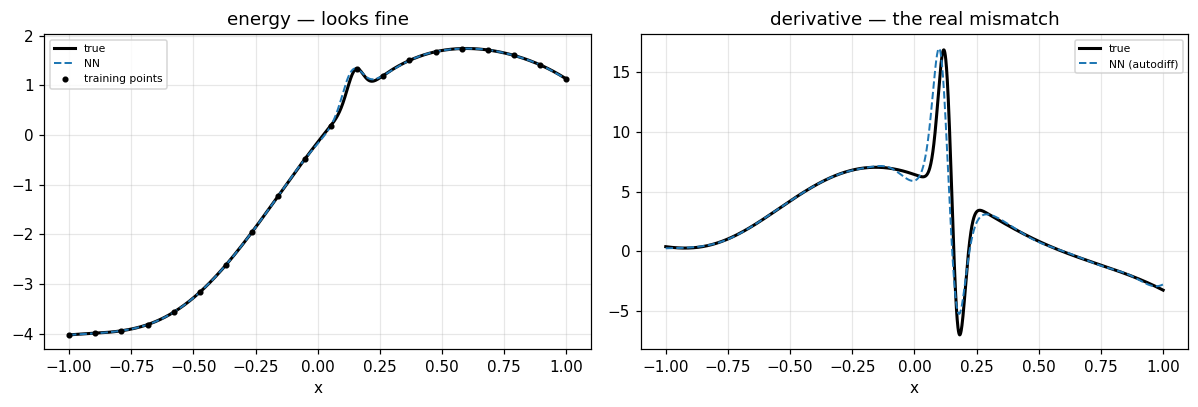

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(xd, energy_true(xd), 'k', lw=2, label='true')
ax[0].plot(xd, E_hat, '--', color='tab:blue', lw=1.3, label='NN')
ax[0].plot(x_tr, energy_true(x_tr), 'k.', ms=6, label='training points')
ax[0].set_title('energy — looks fine'); ax[0].set_xlabel('x'); ax[0].legend(fontsize=7)

ax[1].plot(xd, dE_dx(xd), 'k', lw=2, label='true')
ax[1].plot(xd, dE_hat, '--', color='tab:blue', lw=1.3, label='NN (autodiff)')
ax[1].set_title('derivative — the real mismatch'); ax[1].set_xlabel('x'); ax[1].legend(fontsize=7)
for a_ in ax: a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 1.5 Measuring the surrogate's wavelength

If the surrogate's error has $\lambda \sim h$, reducing $h$ should reduce the derivative error. The number of
training points is swept and both errors measured.

 n_train    h        E MAE      dE/dx MAE   ratio
     8   0.2857    0.10554    1.38088      13.1x
    12   0.1818    0.02650    0.68663      25.9x
    20   0.1053    0.00959    0.33764      35.2x
    40   0.0513    0.00185    0.07880      42.7x
    80   0.0253    0.00085    0.03712      43.5x
   160   0.0126    0.00082    0.03696      44.9x
   320   0.0063    0.00079    0.03632      46.0x
   640   0.0031    0.00077    0.03594      46.8x


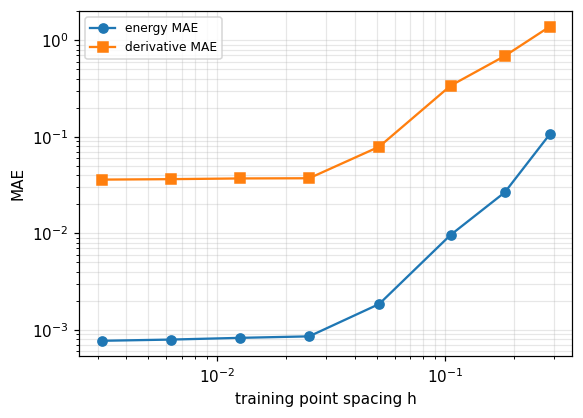

In [27]:
print(" n_train    h        E MAE      dE/dx MAE   ratio")
rows = []
for n in [8, 12, 20, 40, 80, 160, 320, 640]:
    xt = np.linspace(-1, 1, n)
    m = fit_1d(xt, energy_true(xt))
    Eh, gh = value_and_slope(m, xd)
    eE = np.mean(np.abs(Eh - energy_true(xd))); eG = np.mean(np.abs(gh - dE_dx(xd)))
    rows.append((xt[1]-xt[0], eE, eG))
    print(f"   {n:3d}   {xt[1]-xt[0]:.4f}    {eE:.5f}    {eG:.5f}    {eG/eE:6.1f}x")

hs, eEs, eGs = map(np.array, zip(*rows))
plt.figure(figsize=(5.4, 3.9))
plt.loglog(hs, eEs, 'o-', label='energy MAE')
plt.loglog(hs, eGs, 's-', label='derivative MAE')
plt.xlabel('training point spacing h'); plt.ylabel('MAE'); plt.legend(fontsize=8)
plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

Two regimes appear.

At $h = 0.29$ and $0.18$ the derivative error falls quickly as points are added — the sampling-limited regime,
$\lambda \sim h$, as predicted. Below $h \approx 0.03$ it flattens: further points stop helping because the
network's own representation and optimisation floor dominates. That floor is spectral bias, the
high-frequency content of the target that gradient descent does not reach.

The final column is the operative one. **The derivative error is 13–47x the energy error at every spacing.**
A good energy fit never implies a good slope. In the DFT case reducing the spacing is expensive, since each
point is a separate VASP run.
## 1.6 The activation is not a detail

A `ReLU` network produces a derivative that is a staircase. This is neither sampling error nor spectral bias
but a structural constraint: a piecewise-linear model has a piecewise-*constant* derivative and cannot
represent a smooth slope however well it fits the energy.

The general point is that the shape of a derivative error identifies its origin. A staircase indicates the
activation; smooth oscillation between points indicates interpolation. The two require different remedies.

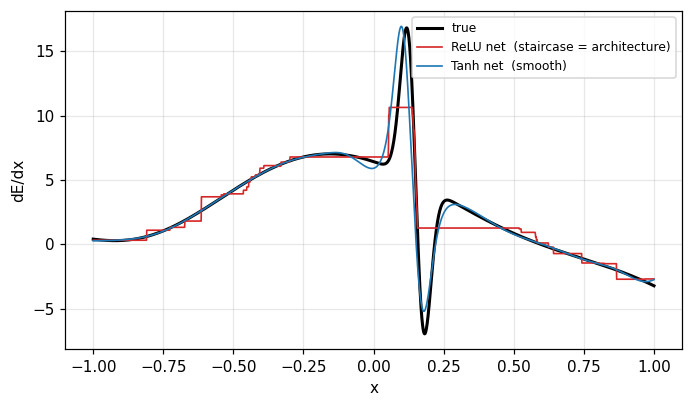

ReLU derivative MAE 0.6500   Tanh derivative MAE 0.3376


In [19]:
m_relu = fit_1d(x_tr, energy_true(x_tr), act=nn.ReLU)
_, g_relu = value_and_slope(m_relu, xd)

plt.figure(figsize=(6.4, 3.8))
plt.plot(xd, dE_dx(xd), 'k', lw=2, label='true')
plt.plot(xd, g_relu, color='tab:red',  lw=1.1, label='ReLU net  (staircase = architecture)')
plt.plot(xd, dE_hat, color='tab:blue', lw=1.1, label='Tanh net  (smooth)')
plt.xlabel('x'); plt.ylabel('dE/dx'); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"ReLU derivative MAE {np.mean(np.abs(g_relu-dE_dx(xd))):.4f}   "
      f"Tanh derivative MAE {np.mean(np.abs(dE_hat-dE_dx(xd))):.4f}")

**Part 1 conclusion.** Differentiation is reliable only when the error is long-$\lambda$. PBE's strain error
is long-$\lambda$, which is why deformation potentials survive a 50% gap error. A surrogate's error is
short-$\lambda$ by construction, from sampling and from spectral bias, so fitting energies more accurately
does not repair its derivative. The remedy has to change *what the model is trained on*.

---
# Part 2 — putting the derivative in the loss

Two remedies, with different costs.

**Active / iterative learning.** Add training points where the model is uncertain. This works — more points
means larger $\lambda$ — but §1.5 shows the return saturates, and each additional point is a VASP run. The
obstacle is cost, not availability.

**Gradient-domain training.** Put the derivative in the loss and train once. If the slope is penalised
directly, the model is no longer free to oscillate between training points, because oscillation now carries a
loss penalty. No loop is required.

This is what an `MLIP` does: it fits total energy $E$ and forces $F = -dE/dR$ jointly. It is affordable
because of **Hellmann–Feynman** — for an eigenstate,
$dE/d\lambda = \langle\psi|\partial H/\partial\lambda|\psi\rangle$, so DFT returns forces alongside the energy
with no additional self-consistency. One configuration of $N$ atoms supplies 1 energy label and $3N$ force
labels; training on energies alone discards most of the available data.

## 2.1 The smallest system that is still an MLIP

A 1-D chain of 4 atoms with nearest-neighbour Morse bonds, $E$ and $F$ known analytically.

In [20]:
D, alpha, r0, N = 1.0, 1.5, 1.0, 4

def V(d):  return D*(1 - np.exp(-alpha*(d-r0)))**2
def dV(d): return 2*D*alpha*(1 - np.exp(-alpha*(d-r0)))*np.exp(-alpha*(d-r0))

def ref(X):
    '''exact E and F for chain configurations X of shape (M, N)'''
    d = X[:, 1:] - X[:, :-1]                 # bond lengths
    E = V(d).sum(1)
    g = dV(d)                                # dE/dd_k
    F = np.zeros_like(X)                     # F_i = -dE/dx_i = g_i - g_{i-1}
    F[:, :-1] += g
    F[:, 1:]  -= g
    return E, F

rng = np.random.default_rng(1)
x0 = np.arange(N)*r0
def sample(M, rattle=0.12): return x0[None, :] + rng.normal(0, rattle, (M, N))

Xtr = sample(120); Etr, Ftr = ref(Xtr)
Xte = sample(400); Ete, Fte = ref(Xte)

# forces must be minus the numerical gradient of the energy
hh, Xc = 1e-6, sample(5); Fnum = np.zeros_like(Xc)
for i in range(N):
    Xp, Xm = Xc.copy(), Xc.copy(); Xp[:, i] += hh; Xm[:, i] -= hh
    Fnum[:, i] = -(ref(Xp)[0] - ref(Xm)[0])/(2*hh)
assert np.allclose(Fnum, ref(Xc)[1], atol=1e-6)
print("analytic forces verified against finite difference")
print(f"E spread {Ete.std():.3f}   F rms {np.sqrt((Fte**2).mean()):.3f}")

analytic forces verified against finite difference
E spread 0.281   F rms 1.611


## 2.2 Descriptor: build the symmetry in rather than learning it

The network does not see atomic positions. It sees **bond lengths** $d_k = x_{k+1} - x_k$. Translating the
chain leaves every $d_k$ unchanged, so the predicted energy is exactly translation-invariant by construction.
Given raw positions the model would have to learn that symmetry from data and would satisfy it only
approximately.

This is the 1-D analogue of what equivariant MLIPs do in three dimensions with rotations, and of the
Behler–Parrinello decomposition (PRL 98, 146401). Forces are still taken with respect to positions: autograd
applies the chain rule through the descriptor.

In [21]:
class MLIP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(N-1, 64), nn.Tanh(),
                                 nn.Linear(64, 64),  nn.Tanh(), nn.Linear(64, 1))
    def forward(self, X):                       # X: (M, N) positions
        return self.net(X[:, 1:] - X[:, :-1]).squeeze(-1)

def energy_and_forces(model, X):
    X = X.clone().requires_grad_(True)
    E = model(X)
    g, = torch.autograd.grad(E.sum(), X, create_graph=True)   # create_graph: we backprop THROUGH this
    return E, -g

def fit_chain(use_forces, epochs=8000, seed=0):
    torch.manual_seed(seed)
    m = MLIP(); opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    X = torch.tensor(Xtr, dtype=torch.float32)
    E = torch.tensor(Etr, dtype=torch.float32)
    F = torch.tensor(Ftr, dtype=torch.float32)
    for _ in range(epochs):
        Ep, Fp = energy_and_forces(m, X)
        loss = ((Ep - E)**2).mean()
        if use_forces:
            loss = loss + ((Fp - F)**2).mean()               # <-- the entire fix
        opt.zero_grad(); loss.backward(); opt.step()
    return m

m_E  = fit_chain(False)
m_EF = fit_chain(True)
print("trained both")

trained both


`create_graph=True` is load-bearing. The force is itself a gradient, so including it in the loss requires the
optimiser to differentiate *through* a gradient — second derivatives of the network. Without `create_graph`
that path is discarded and the force term contributes nothing to the update.

There is also no separate force network. $F$ is $-\nabla E$ of the same scalar model, so the field is
conservative by construction: energy and slope cannot disagree, and energy is conserved in dynamics. A model
predicting forces independently carries no such guarantee. This self-consistency, rather than the added
parameters, is why the approach works.

held out, 400 configurations
energy only      E MAE 0.0110 ( 3.9%)    F MAE 0.1149 ( 7.1%)
energy+forces    E MAE 0.0017 ( 0.6%)    F MAE 0.0162 ( 1.0%)

force error improved 7.1x by adding one term to the loss


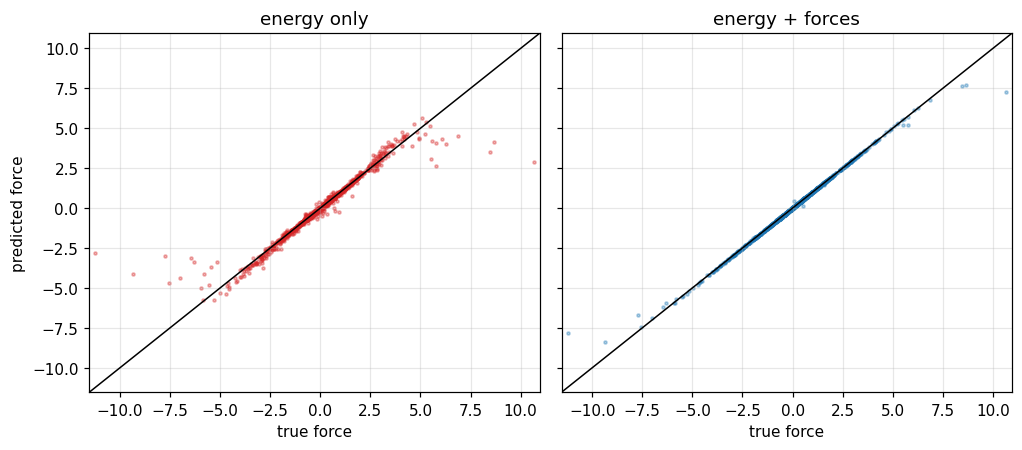

In [22]:
def report(m, tag):
    Xt = torch.tensor(Xte, dtype=torch.float32)
    Ep, Fp = energy_and_forces(m, Xt)
    Ep, Fp = Ep.detach().numpy(), Fp.detach().numpy()
    off = np.mean(Ep - Ete)                      # energy defined up to a constant
    eE = np.mean(np.abs(Ep - off - Ete)); eF = np.mean(np.abs(Fp - Fte))
    print(f"{tag:16s} E MAE {eE:.4f} ({100*eE/Ete.std():4.1f}%)    F MAE {eF:.4f} ({100*eF/np.sqrt((Fte**2).mean()):4.1f}%)")
    return Fp, eF

print("held out, 400 configurations")
FpE, eFE = report(m_E,  "energy only")
FpF, eFF = report(m_EF, "energy+forces")
print(f"\nforce error improved {eFE/eFF:.1f}x by adding one term to the loss")

fig, ax = plt.subplots(1, 2, figsize=(9.4, 4.2), sharex=True, sharey=True)
lim = [Fte.min()-.3, Fte.max()+.3]
for k, (Fp, tag, c) in enumerate([(FpE, 'energy only', 'tab:red'), (FpF, 'energy + forces', 'tab:blue')]):
    ax[k].plot(lim, lim, 'k-', lw=1)
    ax[k].scatter(Fte.ravel(), Fp.ravel(), s=4, alpha=.35, color=c)
    ax[k].set_title(tag); ax[k].set_xlabel('true force'); ax[k].grid(alpha=.3)
ax[0].set_ylabel('predicted force'); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
plt.tight_layout(); plt.show()

Energy-only training produces a visibly scattered force cloud even though its energy is reproduced to a few
percent — the Part 1 pattern again, an acceptable value fit concealing an unacceptable slope. A single
additional loss term collapses the cloud onto the diagonal.

The remedy is therefore both real and cheap, which raises the question of whether it applies to the target
problem.

---
# Part 3 — where this stops transferring

Part 2 addressed $dE_\text{total}/dR$: total energy differentiated with respect to atomic positions. The
quantity required here is $\Xi = dE_\text{band}/d\varepsilon$. **Both terms differ.**

| | MLIP | this problem |
|---|---|---|
| numerator | total energy | a single Kohn–Sham eigenvalue |
| denominator | $3N$ local displacements | 6 global strain components |
| derivative labels | forces, free via Hellmann–Feynman | none — a band energy has no force |

A standard MLIP does not predict band energies, and there is no inexpensive derivative label to place in the
loss. Eigenvalues do something total energies do not: they
become **non-differentiable at degeneracies**. The $\pi_{44}$ channel sits exactly there — a
symmetry-protected zero at the $\Delta$-valley degeneracy, broken only at higher order.

## 3.1 Smallest model that exposes it

A 2×2 Hamiltonian parameterised by strain — a two-level tight-binding toy with two orbitals and one coupling:

$$H(\varepsilon) = \begin{pmatrix} E_0 + a\varepsilon & b\varepsilon + t \\ b\varepsilon + t & E_0 - a\varepsilon\end{pmatrix},
\qquad \lambda_\pm = E_0 \pm \sqrt{(a\varepsilon)^2 + (b\varepsilon+t)^2}.$$

The parameter $t$ controls the gap at $\varepsilon=0$:
large $t$ gives two well-separated bands, $t \to 0$ an exact crossing.

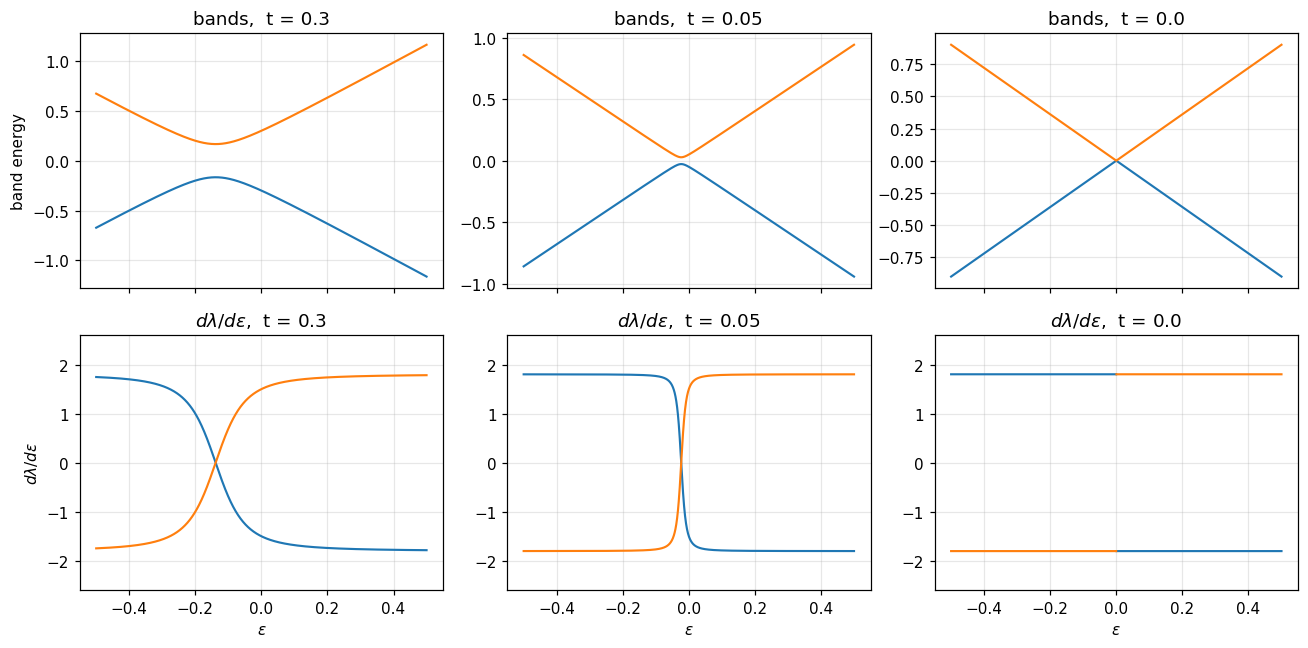

slope magnitude away from eps=0 when t=0 : 1.8027756377319946


In [23]:
a, b, E0 = 1.0, 1.5, 0.0

def lam_np(e, t):
    r = np.sqrt((a*e)**2 + (b*e+t)**2); return E0-r, E0+r

def dlam_np(e, t):
    r = np.sqrt((a*e)**2 + (b*e+t)**2)
    with np.errstate(invalid='ignore', divide='ignore'):
        dr = (a*a*e + b*(b*e+t))/r          # 0/0 exactly at a degeneracy -> nan, on purpose
    return -dr, dr

e = np.linspace(-0.5, 0.5, 2001)
fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for j, t in enumerate([0.3, 0.05, 0.0]):
    lo, hi = lam_np(e, t); dlo, dhi = dlam_np(e, t)
    ax[0, j].plot(e, lo, lw=1.4); ax[0, j].plot(e, hi, lw=1.4)
    ax[0, j].set_title(f'bands,  t = {t}')
    ax[1, j].plot(e, dlo, lw=1.4); ax[1, j].plot(e, dhi, lw=1.4)
    ax[1, j].set_title(f'$d\\lambda/d\\varepsilon$,  t = {t}'); ax[1, j].set_ylim(-2.6, 2.6)
    ax[1, j].set_xlabel(r'$\varepsilon$')
    for r_ in (0, 1): ax[r_, j].grid(alpha=.3)
ax[0, 0].set_ylabel('band energy'); ax[1, 0].set_ylabel(r'$d\lambda/d\varepsilon$')
plt.tight_layout(); plt.show()
print("slope magnitude away from eps=0 when t=0 :", np.sqrt(a*a + b*b))

The left column is the benign case — smooth bands, smooth deformation potential. The middle column is already
problematic: the band still appears smooth, but its derivative carries a feature of width $\sim t/a = 0.05$ in
strain. The right column is degenerate: the band has a kink and the deformation potential is a **step
function**, jumping from $-\sqrt{a^2+b^2}$ to $+\sqrt{a^2+b^2}$ with nothing between. At $\varepsilon = 0$
there is no deformation potential at all — the derivative does not exist.

The middle column is Part 1 restated. The feature width $t/a$ *is* the wavelength $\lambda$, and as $t \to 0$
the amplification $2\pi/\lambda$ diverges. Degeneracies are not a separate problem but the limiting case of
the one already measured.

## 3.2 Autodiff at a degeneracy

If the derivative does not exist, the question is what `torch.autograd` returns when differentiating through
an eigensolver at that point. An error would be the safe outcome. It is not what occurs.

In [24]:
print("d(upper band)/d(eps) via autograd through torch.linalg.eigvalsh")
print("-"*66)
for t in [0.3, 0.0]:
    for e0 in [0.2, 0.0]:
        eps = torch.tensor(e0, dtype=torch.float64, requires_grad=True)
        H = torch.stack([torch.stack([E0 + a*eps, b*eps + t]),
                         torch.stack([b*eps + t, E0 - a*eps])])
        g = torch.autograd.grad(torch.linalg.eigvalsh(H)[1], eps)[0].item()
        exact = dlam_np(e0, t)[1]
        if np.isnan(exact):
            print(f"t={t:<5} eps={e0:<5} autodiff {g:+.6f}   exact DOES NOT EXIST (kink)"
                  f"   <-- silently wrong, no NaN raised")
        else:
            print(f"t={t:<5} eps={e0:<5} autodiff {g:+.6f}   exact {exact:+.6f}"
                  f"{'   ok' if abs(g-exact)<1e-6 else '   <-- WRONG'}")

d(upper band)/d(eps) via autograd through torch.linalg.eigvalsh
------------------------------------------------------------------
t=0.3   eps=0.2   autodiff +1.739253   exact +1.739253   ok
t=0.3   eps=0.0   autodiff +1.500000   exact +1.500000   ok
t=0.0   eps=0.2   autodiff +1.802776   exact +1.802776   ok
t=0.0   eps=0.0   autodiff -1.000000   exact DOES NOT EXIST (kink)   <-- silently wrong, no NaN raised


At the degeneracy the derivative does not exist; the one-sided limits are $\pm 1.803$. Autodiff returns
$-1.0$, which is neither, and does so with **no NaN, no warning and no exception**. The returned value is not
a derivative of anything, and inside a training loop it would pass unnoticed.

The reason: the gradient of an eigenvalue with respect to the matrix is $\psi\psi^\top$, which requires a
definite eigenvector. At an exact degeneracy the eigenvectors are undetermined — any basis of the degenerate
subspace diagonalises $H$ equally well — so LAPACK (Lin-Algebra package behind the algorithms) returns an arbitrary one and autograd differentiates
faithfully using a basis with no physical meaning. Verified below.

In [25]:
H0 = np.array([[E0, 0.0], [0.0, E0]])       # degenerate H at eps = 0, t = 0
dH = np.array([[a, b], [b, -a]])            # dH/d(eps)
w, Vv = np.linalg.eigh(H0)

print("eigenvectors LAPACK returns at the degeneracy (arbitrary — any basis works):")
print(Vv)
print("\nnaive Hellmann-Feynman  <psi_i|dH/de|psi_i> :", np.round([Vv[:, i] @ dH @ Vv[:, i] for i in range(2)], 6))
print("degenerate PT, eigenvalues of dH/de in the subspace:", np.round(np.linalg.eigvalsh(dH), 6))
print("exact one-sided slopes from the |eps| formula      :",
      np.round([-np.sqrt(a*a+b*b), np.sqrt(a*a+b*b)], 6))
assert np.allclose(np.linalg.eigvalsh(dH), [-np.sqrt(a*a+b*b), np.sqrt(a*a+b*b)])
print("\ndegenerate perturbation theory recovers the exact slopes; naive HF does not")

eigenvectors LAPACK returns at the degeneracy (arbitrary — any basis works):
[[1. 0.]
 [0. 1.]]

naive Hellmann-Feynman  <psi_i|dH/de|psi_i> : [ 1. -1.]
degenerate PT, eigenvalues of dH/de in the subspace: [-1.802776  1.802776]
exact one-sided slopes from the |eps| formula      : [-1.802776  1.802776]

degenerate perturbation theory recovers the exact slopes; naive HF does not


The correct procedure at a degeneracy is therefore not to differentiate the band. It is to take
$dH/d\varepsilon$, project it onto the degenerate subspace and **diagonalise that**; its eigenvalues are the
slopes. This is first-order degenerate perturbation theory, and it is a statement about an *operator* rather
than about a band.

This is also where plain Hellmann–Feynman — the theorem that made Part 2 affordable — ceases to apply, since
it assumes a non-degenerate eigenstate.

## 3.3 Consequence for surrogates: regress $H$, not the band

$H(\varepsilon)$ is smooth through the degeneracy. The non-analyticity is produced by the eigensolver, not by
the physics, which suggests predicting $H$ and diagonalising afterwards.

The claim is testable. Same network, same data, same training: route A regresses the band energy, route B the
matrix elements, with diagonalisation applied after. Setting $t = 0.02$ makes the avoided-crossing feature
narrower than the training point spacing — the realistic case, since a dense strain mesh in VASP is not
affordable.

training spacing 0.0250   feature width ~ t/a = 0.0200   -> unresolved

------------------------------------------------------------------------
A band regression    band MAE 0.00128    dband MAE 0.07491    near crossing 0.36804
B H regression       band MAE 0.00749    dband MAE 0.02635    near crossing 0.16502
------------------------------------------------------------------------
near the crossing, route B is 2.2x better on the derivative


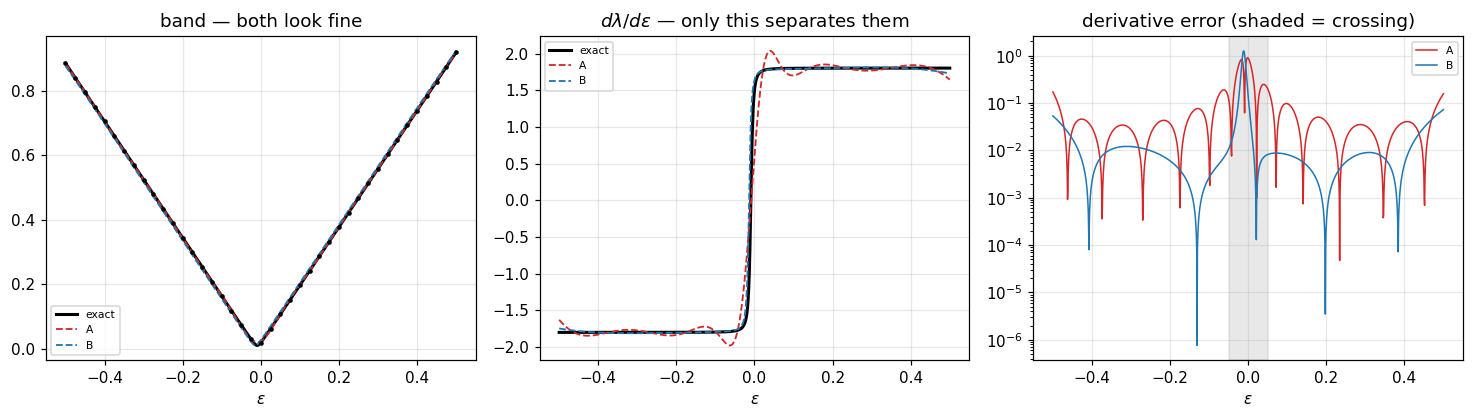

In [26]:
T, W, NTR = 0.02, 0.5, 41
etr = np.linspace(-W, W, NTR); ede = np.linspace(-W, W, 1201)
print(f"training spacing {etr[1]-etr[0]:.4f}   feature width ~ t/a = {T/a:.4f}   -> unresolved")

def mlp(nin, nout):
    return nn.Sequential(nn.Linear(nin, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, nout))

X = torch.tensor(etr, dtype=torch.float32).view(-1, 1)

torch.manual_seed(0)                                    # route A: band regression
mA = mlp(1, 1); optA = torch.optim.Adam(mA.parameters(), lr=3e-3)
YA = torch.tensor(lam_np(etr, T)[1], dtype=torch.float32).view(-1, 1)
for _ in range(8000):
    l = ((mA(X) - YA)**2).mean(); optA.zero_grad(); l.backward(); optA.step()
xd1 = torch.tensor(ede, dtype=torch.float32).view(-1, 1).requires_grad_(True)
EA = mA(xd1); dA, = torch.autograd.grad(EA.sum(), xd1)
EA, dA = EA.detach().numpy().ravel(), dA.detach().numpy().ravel()

torch.manual_seed(0)                                    # route B: H regression, diagonalise after
mB = mlp(1, 3); optB = torch.optim.Adam(mB.parameters(), lr=3e-3)
YB = torch.tensor(np.stack([E0 + a*etr, b*etr + T, E0 - a*etr], 1), dtype=torch.float32)
for _ in range(8000):
    l = ((mB(X) - YB)**2).mean(); optB.zero_grad(); l.backward(); optB.step()
def upper_band(h):
    h11, h12, h22 = h[:, 0], h[:, 1], h[:, 2]
    return (h11 + h22)/2 + torch.sqrt(((h11 - h22)/2)**2 + h12**2)
xd2 = torch.tensor(ede, dtype=torch.float32).view(-1, 1).requires_grad_(True)
EB = upper_band(mB(xd2)); dB, = torch.autograd.grad(EB.sum(), xd2)
EB, dB = EB.detach().numpy().ravel(), dB.detach().numpy().ravel()

lt, dt = lam_np(ede, T)[1], dlam_np(ede, T)[1]
core = np.abs(ede) < 0.05
print("\n" + "-"*72)
for tag, Ey, dy in [("A band regression", EA, dA), ("B H regression", EB, dB)]:
    print(f"{tag:20s} band MAE {np.mean(np.abs(Ey-lt)):.5f}    "
          f"dband MAE {np.mean(np.abs(dy-dt)):.5f}    near crossing {np.mean(np.abs(dy-dt)[core]):.5f}")
print("-"*72)
print(f"near the crossing, route B is {np.mean(np.abs(dA-dt)[core])/np.mean(np.abs(dB-dt)[core]):.1f}x better on the derivative")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
ax[0].plot(ede, lt, 'k', lw=2, label='exact'); ax[0].plot(ede, EA, '--', color='tab:red', lw=1.2, label='A')
ax[0].plot(ede, EB, '--', color='tab:blue', lw=1.2, label='B'); ax[0].plot(etr, lam_np(etr, T)[1], 'k.', ms=4)
ax[0].set_title('band — both look fine')
ax[1].plot(ede, dt, 'k', lw=2, label='exact'); ax[1].plot(ede, dA, '--', color='tab:red', lw=1.2, label='A')
ax[1].plot(ede, dB, '--', color='tab:blue', lw=1.2, label='B'); ax[1].set_title(r'$d\lambda/d\varepsilon$ — only this separates them')
ax[2].semilogy(ede, np.abs(dA-dt)+1e-12, color='tab:red', lw=1, label='A')
ax[2].semilogy(ede, np.abs(dB-dt)+1e-12, color='tab:blue', lw=1, label='B')
ax[2].axvspan(-0.05, 0.05, color='gray', alpha=.18); ax[2].set_title('derivative error (shaded = crossing)')
for a_ in ax: a_.grid(alpha=.3); a_.set_xlabel(r'$\varepsilon$'); a_.legend(fontsize=7)
plt.tight_layout(); plt.show()

The left panel is the trap: both surrogates reproduce the band to roughly 3 parts in a thousand and are
indistinguishable by eye, so either would pass validation on band energies. The remaining panels show route
A's deformation potential is wrong by order 100% precisely in the crossing region. Same network, same data;
the only difference is which quantity was regressed.

**Caveat.** The matrix elements here are *linear* in $\varepsilon$, so route B has an unusually easy target
and the improvement factor is inflated. The qualitative result — $H$ is smooth through a degeneracy and
eigenvalues are not — is robust and carries the content; the numerical factor does not transfer.

---
# Consequences for $\pi_{44}$

Combining the three parts.

Differentiation is reliable only when the surrogate's error is long-wavelength. Fitting energies accurately
does not make it so — sampling gives $\lambda \sim h$, and spectral bias leaves the high frequencies
unlearned. Training on derivatives does fix it, which is why MLIPs work and why they were the right reference
point. But the MLIP recipe transfers only in spirit: the differentiated object is an eigenvalue rather than a
total energy, the variable is a global strain rather than a local displacement, there is no inexpensive
derivative label, and the point of interest is a degeneracy, where the target derivative does not exist and
the eigensolver's gradient is silently basis-dependent.

For $\pi_{44}$ this is not a corner case but the governing physics. The zero is symmetry-protected at the
$\Delta$-valley degeneracy and broken only at higher order through $\Delta_1$–$\Delta_{2'}$ coupling, so the
quantity of interest is a *small difference of slopes* evaluated exactly where a surrogate is least reliable.
A band-energy surrogate is therefore untrustworthy for it at any training density: §3.3 shows the failure is
one of representability rather than sampling, so additional points do not remove it.

**What a surrogate would need to do instead.** Predict $H(R;\varepsilon)$ in a local basis rather than band
energies — the DeepH class (Li et al., Nat. Comput. Sci. 2, 367 (2022)). Diagonalise afterwards, so the
non-analytic step is performed in exact arithmetic rather than inside the fit. Treat the degenerate subspace
explicitly, diagonalising $P\,(dH/d\varepsilon)\,P$ rather than differentiating individual bands. And impose
the cubic-group equivariance in the model rather than relying on it being learned, since a symmetry-protected
zero that the surrogate protects only approximately yields a $\pi_{44}$ that is wrong for a reason invisible
to any energy-based validation metric.

**Open question.** Even with $H(\varepsilon)$ predicted exactly, $\pi_{44}$ in n-Si requires strain-modified
*scattering* beyond the constant-$\tau$ relaxation-time approximation. A surrogate improves band-structure
sampling density, which is not the limiting factor. Whether a DeepH-style $H(R;\varepsilon)$ is therefore
genuinely useful for the $\pi_{44}$ channel, or only accelerates a step that is already tractable, is the
question this notebook was built to ask.

---
## Appendix — practical notes

Points that cost time here and are easy to get wrong in this kind of experiment.

- **Splitting sorted data contiguously is extrapolation, not validation.** With a sorted grid, contiguous
  slices put training on one part of the domain and validation on another. The relevant property is domain
  coverage; for deterministic noiseless data there is no distribution to represent.
- **Smoothing of sharp features is not regularisation.** With no weight decay and no dropout, the mechanism
  is spectral bias — a property of gradient-descent dynamics rather than a tunable setting.
- **A slope is not a force.** In Part 1 the quantity is $dE/dx$ for a scalar function. A force is
  $-dE_\text{total}/dR$ with respect to atomic positions and does not appear until Part 2. Part 3 turns
  entirely on such numerator/denominator distinctions.
- **Active learning and gradient-domain training are different remedies.** The first adds points in a loop;
  the second adds a derivative term to the loss and trains once.
- **In DFT the derivative is the inexpensive half.** Hellmann–Feynman supplies forces alongside the energy;
  for active learning the constraint is cost per call, not availability of derivatives.
- **Optimiser binding.** `torch.optim.Adam(model.parameters(), ...)` captures the parameters of the model
  object existing at that moment. Rebuilding the model afterwards leaves the optimiser updating the previous
  object, and training silently fails. Model and optimiser are therefore always constructed together.
- **Autodiff requires `requires_grad_(True)` on the input** and no `torch.no_grad()` around the forward pass.
- **The shape of a derivative error identifies its cause.** A staircase indicates a piecewise-linear
  activation; smooth oscillation between points indicates interpolation error. Only the second is relevant to
  a DFT surrogate.